# Waveoptics: Arago-Poisson spot

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

try:
    import srxraylib.plot.gol as _gol
    _gol.set_qt = lambda: None
except Exception:
    pass


SRW is not available

#                                                             
# 2D near field fresnel (fresnel (fft)) diffraction from a a circular stop  
#                                                             


/tmp/ipykernel_1982107/3593000607.py:33: DeprecationWarning: Call to deprecated function propagate_2D_fresnel (use wofry and wofrylib, instead).
  wf1 = propagate_2D_fresnel(wf, propagation_distance)


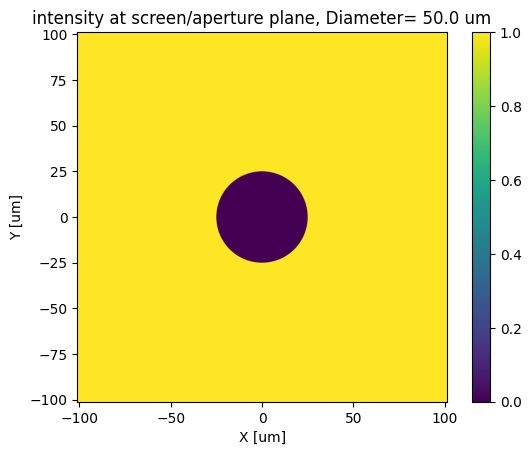

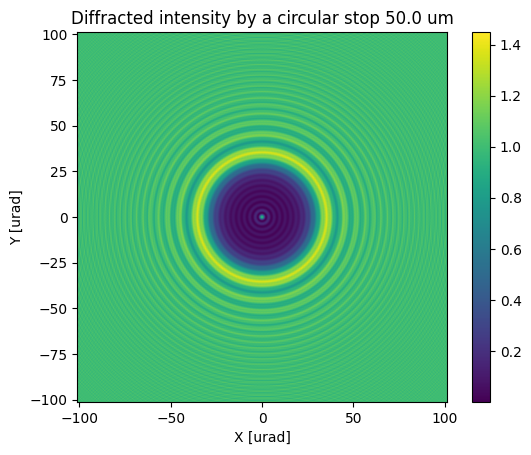

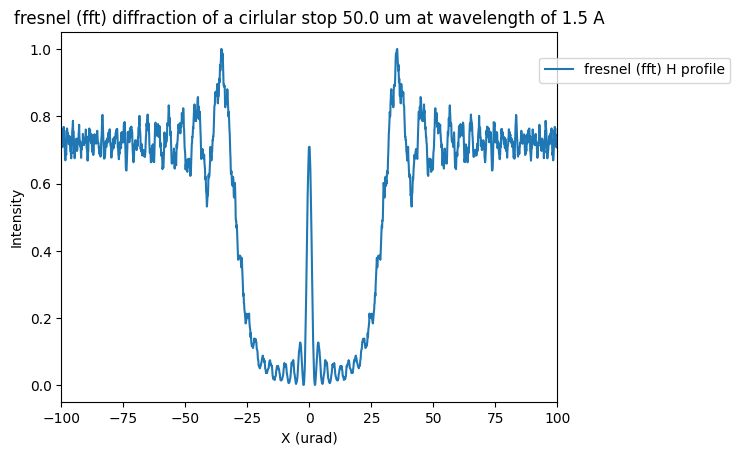

In [2]:
from srxraylib.waveoptics.wavefront2D import Wavefront2D
from srxraylib.waveoptics.propagator2D import propagate_2D_fresnel
from srxraylib.plot.gol import plot,plot_image


if __name__ == "__main__":

    wavelength=0.15e-9
    aperture_diameter=50e-6
    pixelsize_x=1e-7
    pixelsize_y=1e-7
    npixels_x=2024
    npixels_y=2024
    propagation_distance = 1.0
    show=1

    method_label = "fresnel (fft)"
    print("\n#                                                             ")
    print("# 2D near field fresnel (%s) diffraction from a a circular stop  "%(method_label))
    print("#                                                             ")


    wf = Wavefront2D.initialize_wavefront_from_range(x_min=-pixelsize_x*npixels_x/2,x_max=pixelsize_x*npixels_x/2,
                                                     y_min=-pixelsize_y*npixels_y/2,y_max=pixelsize_y*npixels_y/2,
                                                     number_of_points=(npixels_x,npixels_y),wavelength=wavelength)

    wf.set_plane_wave_from_complex_amplitude((1.0+0j))


    wf.apply_pinhole(aperture_diameter/2,negative=True)


    wf1 = propagate_2D_fresnel(wf, propagation_distance)


    plot_image(wf.get_intensity(),1e6*wf.get_coordinate_x(),1e6*wf.get_coordinate_y(),
               title="intensity at screen/aperture plane, Diameter=%5.1f um"%
                     (1e6*aperture_diameter),xtitle="X [um]",ytitle="Y [um]",
               show=0)

    plot_image(wf1.get_intensity(),
               1e6*wf1.get_coordinate_x()/propagation_distance,
               1e6*wf1.get_coordinate_y()/propagation_distance,
               title="Diffracted intensity by a circular stop %3.1f um"%
                     (1e6*aperture_diameter),
               xtitle="X [urad]",ytitle="Y [urad]",
               show=0)


    intensity_calculated =  wf1.get_intensity()[:,int(wf1.size()[1]/2)]

    intensity_calculated /= intensity_calculated.max()

    plot(wf1.get_coordinate_x()*1e6/propagation_distance,intensity_calculated,
         legend=["%s H profile"%method_label],
         legend_position=(0.95, 0.95),
         title="%s diffraction of a cirlular stop %3.1f um at wavelength of %3.1f A"%
               (method_label,aperture_diameter*1e6,wavelength*1e10),
         xtitle="X (urad)", ytitle="Intensity",xrange=[-100,100],
         show=show)

